# Absolute stability regions of forward and backward Euler

Companion notebook for Section 6.1 (Absolute stability) of `Lec6.tex`. Applying a one-step method to the test ODE
$$
\frac{du}{dt} = \lambda u, \qquad u(0) = c,
$$
gives $u_n = R(z)^n u_0$ with $z = \Delta t \lambda \in \mathbb{C}$, where $R$ is the amplification factor:
$$
R_{\rm FE}(z) = 1 + z, \qquad R_{\rm BE}(z) = \frac{1}{1 - z}.
$$
The region of absolute stability is the set $\{ z \in \mathbb{C} : |R(z)| < 1 \}$. For forward Euler this is the
disk of radius $1$ centered at $-1$; for backward Euler it is the exterior of the disk of radius $1$ centered at $+1$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# grid in the complex z = Delta t * lambda plane
x = np.linspace(-3, 3, 601)
y = np.linspace(-3, 3, 601)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

R_fe = 1 + Z
R_be = 1 / (1 - Z)

/tmp/ipykernel_720427/2141918649.py:8: RuntimeWarning: divide by zero encountered in divide
  R_be = 1 / (1 - Z)
/tmp/ipykernel_720427/2141918649.py:8: RuntimeWarning: invalid value encountered in divide
  R_be = 1 / (1 - Z)


In [4]:
def plot_stability_region(ax, R, title):
    # shade the region |R(z)| < 1 and draw its boundary |R(z)| = 1
    ax.contourf(X, Y, np.abs(R), levels=[0, 1], colors=["tab:blue"], alpha=0.4)
    ax.contour(X, Y, np.abs(R), levels=[1], colors="tab:blue", linewidths=2)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.axvline(0, color="k", linewidth=0.8)
    ax.set_xlabel(r"$\mathrm{Re}(\Delta t \lambda)$")
    ax.set_ylabel(r"$\mathrm{Im}(\Delta t \lambda)$")
    ax.set_aspect("equal")
    ax.set_title(title)

saved forward_euler_stability_region.png


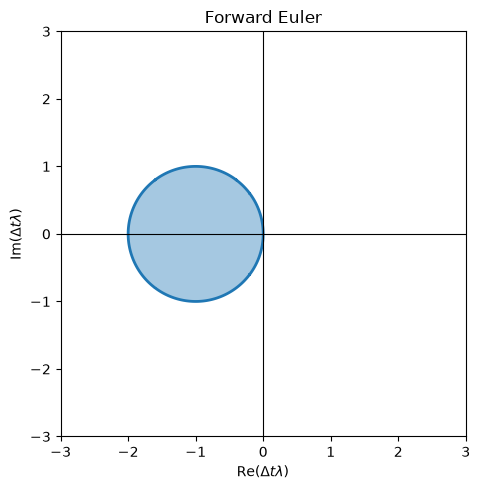

saved backward_euler_stability_region.png


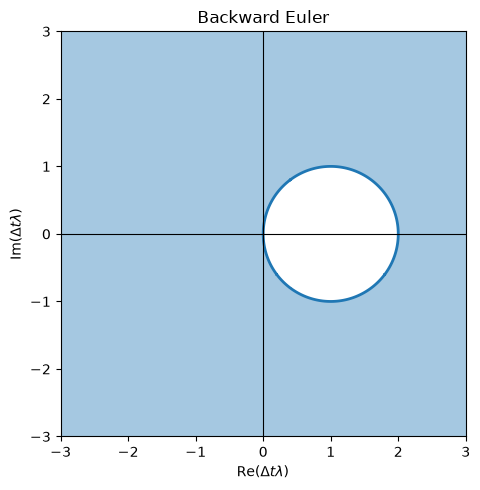

In [5]:
for R, name, filename in [
    (R_fe, "Forward Euler", "forward_euler_stability_region.png"),
    (R_be, "Backward Euler", "backward_euler_stability_region.png"),
]:
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_stability_region(ax, R, rf"{name}")
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"saved {filename}")
    plt.show()

Forward Euler is stable only for $\Delta t \lambda$ in a bounded disk, so for $\mathrm{Re}(\lambda) < 0$ the time step
must be small enough to keep $\Delta t \lambda$ inside it. Backward Euler is stable on the entire left half-plane
(and more), so it is stable for any $\Delta t > 0$ whenever $\mathrm{Re}(\lambda) < 0$.